# `FeatureTransformer` — автоматическая нормализация числовых признаков

`sklearn`-совместимый трансформер (`fit` / `transform` / `fit_transform`), который для каждой числовой
колонки сам определяет тип распределения и подбирает подходящее преобразование из элементарных функций,
приближающее данные к нормальному, а затем нормирует выбранным скейлером.

Поддерживаемые случаи и реакция на них:

- **похожее на нормальное** и **мультимодальное** — только нормировка;
- **скошенное вправо / влево** (обычно и сильно) — Box-Cox / Yeo-Johnson с автоподбором λ;
- **равномерное** — обратная функция нормального распределения от `MinMax`;
- **категориальное** (мало уникальных значений, порог `cat_thr`) — без трансформации.

`QuantileTransformer` используется только как опциональный фолбэк (`use_quantile_transformer=True`) для случаев,
которые не удаётся аккуратно описать элементарной функцией — чтобы не «замыливать» данные тяжёлой непараметрикой по умолчанию.

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.preprocessing import (
    StandardScaler,
    MinMaxScaler,
    MaxAbsScaler,
    RobustScaler,
    QuantileTransformer,
    PowerTransformer
)

from scipy import stats
from scipy.signal import find_peaks


plt.style.use('seaborn-v0_8-darkgrid')

In [2]:
def plot_comparison(df_original, df_transformed, cols=None):
    """
    Рисует 4 графика для каждой колонки:
    - Левый столбец: Оригинал (Лин. и Лог. шкалы)
    - Правый столбец: Трансформация (Лин. и Лог. шкалы)
    """
    if cols is None:
        cols = df_original.columns

    print(f"\n--- Сравнение распределений 'До' и 'После' ---")

    for col in cols:
        if col not in df_original.columns or col not in df_transformed.columns:
            print(
                f"Пропуск колонки {col}: отсутствует в одном из датафреймов.")
            continue

        fig, ax = plt.subplots(1, 4, figsize=(12, 3))
        fig.suptitle(f"Колонка: {col}", fontsize=14)

        ax[0].set_title(f"Original (Linear)")
        ax[0].hist(df_original[col].dropna(), bins=33, color='blue', alpha=0.7)

        ax[1].set_title(f"Original (Log)")
        ax[1].hist(df_original[col].dropna(), bins=33, color='blue', alpha=0.7)
        ax[1].set_yscale('log')

        ax[2].set_title(f"Transformed (Linear)")
        ax[2].hist(df_transformed[col].dropna(),
                   bins=33, color='red', alpha=0.7)

        ax[3].set_title(f"Transformed (Log)")
        ax[3].hist(df_transformed[col].dropna(),
                   bins=33, color='red', alpha=0.7)
        ax[3].set_yscale('log')


        fig.tight_layout(rect=[0, 0.03, 1, 0.95])
        plt.show()

In [3]:
class FeatureTransformer:
    def __init__(self, scaler='StandardScaler', use_quantile_transformer=False, cat_thr=10, random_state=42, *args, **kwargs):
        '''
        scaler: str in ('StandardScaler', 'MinMaxScaler', 'MaxAbsScaler', 'RobustScaler') or None
            -- вариант нормализации данных после трансформаций. None -- без нормализации.

        use_quantile_transformer: Если True, то в случаях, когда мы затрудняемся определить подходящую трансформацию из элементарных функций,
            используем sklearn.preprocessing.QuantileTransformer. Если False, то для таких колонок не используем трансформацию.

        cat_thr: если в колонке количество уникальных значений < cat_thr,
            мы ее считаем за категориальную и не трансформируем (нормализацию делаем)
        '''
        self.scaler_name = scaler
        self.use_quantile_transformer = use_quantile_transformer
        self.cat_thr = cat_thr
        self.random_state = random_state

        self._scaler_map = {
            'StandardScaler': StandardScaler,
            'MinMaxScaler': MinMaxScaler,
            'MaxAbsScaler': MaxAbsScaler,
            'RobustScaler': RobustScaler
        }

        if scaler not in self._scaler_map and scaler is not None:
            raise ValueError(
                f"Неизвестный scaler: {scaler}. Допустимые: {list(self._scaler_map.keys())} или None.")

        # Словари для хранения обученных объектов и метаданных
        self._scalers = {}          # Будет хранить {col: scaler_instance}
        self._transformations = {}  # Будет хранить {col: transform_name_or_func}

        self.cat_cols_ = []
        self.multimodal_cols_ = []
        self.normal_like_cols_ = []
        self.uniform_cols_ = []
        self.right_skew_cols_ = []
        self.strong_right_skew_cols_ = []
        self.left_skew_cols_ = []
        self.strong_left_skew_cols_ = []


    def fit(self, X, *args, **kwargs):
        '''
        "Обучаем" наш трансформатор -- собираем все необходимые данные на обучающей выборке, напр. mean, std для StandardScaler,
            а также "записываем", какую трансформацию нужно применить к каждой колонке
        '''
        X_fit = X.copy()

        # 1. Сброс состояний
        self.cat_cols_ = []
        self.multimodal_cols_ = []
        self.normal_like_cols_ = []
        self.uniform_cols_ = []
        self.right_skew_cols_ = []
        self.strong_right_skew_cols_ = []
        self.left_skew_cols_ = []
        self.strong_left_skew_cols_ = []
        self._scalers = {}
        self._transformations = {}

        all_numeric_cols = X_fit.select_dtypes(include=np.number).columns
        X_fit_transformed = X_fit.copy()

        # 2. Анализ, обучение и сохранение лямбд
        for col in all_numeric_cols:
            col_data = X_fit[col].dropna()

            # Обертка для .fit(X[[col]])
            col_data_2d = col_data.values.reshape(-1, 1)

            transform_name = 'undefined'
            transform_func = lambda x: x

            # --- 1. Категориальные ---
            if col_data.nunique() < self.cat_thr:
                self.cat_cols_.append(col)
                transform_name = 'skip_categorical'

            # --- 2. Мультимодальные ---
            elif self._check_multimodality(col_data):
                self.multimodal_cols_.append(col)
                if self.use_quantile_transformer:
                    qt = QuantileTransformer(output_distribution='normal',
                                             random_state=self.random_state)
                    qt.fit(col_data_2d)
                    transform_name = 'QuantileTransformer(normal)'

                    def transform_func(x, q=qt): return q.transform(
                        x.values.reshape(-1, 1)).ravel()
                else:
                    transform_name = 'skip_multimodal'

            # --- 3. Анализ скошенности и эксцесса ---
            else:
                skewness = col_data.skew()
                kurtosis = col_data.kurt()

                # --- 3a. Нет скошенности ---
                if abs(skewness) < 0.5:
                    if kurtosis < -0.5:
                        self.uniform_cols_.append(col)
                        scaler_01 = MinMaxScaler(
                            feature_range=(1e-6, 1 - 1e-6))
                        scaler_01.fit(col_data_2d)

                        transform_name = 'InverseNormalCDF(MinMax(x))'
                        def transform_func(x, s=scaler_01): return stats.norm.ppf(
                            s.transform(x.values.reshape(-1, 1))).ravel()
                    else:
                        self.normal_like_cols_.append(col)
                        transform_name = 'skip_normal_like'

                # --- 3b. Скошенность ВЛЕВО ---
                elif skewness >= 0.5:
                    # Box-Cox требует x > 0
                    min_val = col_data.min()
                    offset = -min_val + 1e-6 if min_val <= 0 else 0
                    data_for_fit = col_data_2d + offset

                    pt = PowerTransformer(method='box-cox', standardize=False)
                    pt.fit(data_for_fit)
                    lambda_ = pt.lambdas_[0]

                    transform_name = f'Box-Cox(λ={lambda_:.2f}, offset={offset:.2e})'
                    # Обертка, которая добавляет offset и работает с 2D

                    def transform_func(x, o=offset, p=pt): return p.transform(
                        (x + o).values.reshape(-1, 1)).ravel()

                    if skewness < 2.0:
                        self.left_skew_cols_.append(col)
                    else:
                        self.strong_left_skew_cols_.append(col)

                # --- 3c. Скошенность ВПРАВО ---
                elif skewness <= -0.5:
                    pt = PowerTransformer(
                        method='yeo-johnson', standardize=False)
                    pt.fit(col_data_2d)
                    lambda_ = pt.lambdas_[0]

                    transform_name = f'Yeo-Johnson(λ={lambda_:.2f})'
                    # Обертка для 2D
                    def transform_func(x, p=pt): return p.transform(
                        x.values.reshape(-1, 1)).ravel()

                    if skewness > -2.0:
                        self.right_skew_cols_.append(col)
                    else:
                        self.strong_right_skew_cols_.append(col)

            # --- 4. Сохраняем результат ---
            self._transformations[col] = (transform_name, transform_func)

            # --- 5. Применяем лямбду (для обучения скейлера) ---
            try:
                X_fit_transformed[col] = transform_func(X_fit_transformed[col])
            except Exception as e:
                print(
                    f"    - ОШИБКА применения '{col}' в fit: {e}. Скейлер будет обучен на ОРИГИНАЛЕ.")
                X_fit_transformed[col] = X_fit[col]

        # --- 6. Печать СВОДКИ ---
        print("--- Результаты Fit ---")
        print(f"Категориальные ({len(self.cat_cols_)}): {self.cat_cols_}")
        print(
            f"Мультимодальные ({len(self.multimodal_cols_)}): {self.multimodal_cols_}")
        print(
            f"Похожие на норм. ({len(self.normal_like_cols_)}): {self.normal_like_cols_}")
        print(f"Равномерные ({len(self.uniform_cols_)}): {self.uniform_cols_}")
        print(
            f"Скош. вправо ({len(self.right_skew_cols_)}): {self.right_skew_cols_}")
        print(
            f"Сильно скош. вправо ({len(self.strong_right_skew_cols_)}): {self.strong_right_skew_cols_}")
        print(
            f"Скош. влево ({len(self.left_skew_cols_)}): {self.left_skew_cols_}")
        print(
            f"Сильно скош. влево ({len(self.strong_left_skew_cols_)}): {self.strong_left_skew_cols_}")
        print("-----------------------------")

        # 7. Обучаем скейлеры (на ТРАНСФОРМИРОВАННЫХ данных)
        if self.scaler_name:
            print(f"\nОбучение скейлера '{self.scaler_name}'...")
            ScalerClass = self._scaler_map[self.scaler_name]

            for col in all_numeric_cols:
                try:
                    scaler_instance = ScalerClass()
                    scaler_instance.fit(X_fit_transformed[[col]].dropna())
                    self._scalers[col] = scaler_instance
                except Exception as e:
                    print(f"  - Ошибка обучения скейлера для '{col}': {e}")
        else:
            print("Скейлинг отключен.")

        return self

    def transform(self, X, *args, **kwargs):
        '''
        Применяем "записанные" трансформации + нормализацию на все необходимые колонки

        returns:
            X_transformed -- датафрейм размерности X, где все числовые колонки трансформированы (если надо) (+ нормализованы)
        '''
        X_transformed = X.copy()

        print(f"\nTransform: Применение трансформаций...")

        max_len = 0
        if self._transformations:  # Проверка, что словарь не пуст
            max_len = max(len(col) for col in self._transformations.keys()) + 2

        for col, (name, transform_func) in self._transformations.items():
            if col in X_transformed.columns:

                print(f"  - Колонка: {col:<{max_len}} Применяем: {name}")

                try:
                    # Передаем Series, как и ожидает лямбда
                    X_transformed[col] = transform_func(X_transformed[col])
                except Exception as e:
                    print(
                        f"    - ОШИБКА применения трансформации для '{col}': {e}")

        # --- 2. Применение скейлинга ---
        if self._scalers:
            print(f"\nПрименение скейлера '{self.scaler_name}'...")
            for col, scaler_instance in self._scalers.items():
                if col in X_transformed.columns:
                    try:
                        X_transformed[col] = scaler_instance.transform(
                            X_transformed[[col]])
                    except Exception as e:
                        print(
                            f"  - Ошибка применения скейлера для колонки '{col}': {e}")
        else:
            print("\nСкейлинг не применяется.")

        return X_transformed


    def fit_transform(self, X, *args, **kwargs):
        return self.fit(X, *args, **kwargs).transform(X, *args, **kwargs)


    def _check_multimodality(self, data, prominence_threshold_ratio=0.03):
        """
        Проверяет данные на мультимодальность с помощью KDE и find_peaks.

        prominence_threshold_ratio:
            Доля от общего размаха плотности (max - min).
            Пик считается "значимым", если его выступ > (max_density - min_density) * ratio.
        """
        try:
            data_cleaned = data.dropna()

            if len(data_cleaned.unique()) < 3:
                return False

            kde = stats.gaussian_kde(data_cleaned, bw_method='silverman')
            grid = np.linspace(data_cleaned.min(), data_cleaned.max(), 1000)
            density = kde(grid)

            min_density = density.min()
            max_density = density.max()
            prominence_threshold = (
                max_density - min_density) * prominence_threshold_ratio

            if prominence_threshold == 0:
                return False

            peaks, properties = find_peaks(
                density, prominence=prominence_threshold)
            return len(peaks) > 1

        except Exception as e:
            return False

### Демонстрация на наборе модельных распределений

In [4]:
df = pd.read_csv('distributions.csv')
print(f"Загружено: {df.shape}")
df.head()

Загружено: (20640, 16)


,MedInc,HouseAge,Population,AveOccup,Latitude,Longitude,some_lefty_col,some_righty_col,some_righty_col_2,some_strong_righty_col,some_strong_righty_col_2,some_multimodal_col,some_category_col,some_category_col_2,some_uniform_col,some_strange_col
0,8.3252,41.0,322.0,2.555556,37.88,-122.23,0.156464,-0.116708,-5.849171,-325.280177,-7.223948,1.512127,1,2,-2.104405,41.492615
1,8.3014,21.0,2401.0,2.109842,37.86,-122.22,0.163151,-0.083764,-9.821180,-2403.428770,-2.618139,3.022277,1,1,-2.265237,18.116360
2,7.2574,52.0,496.0,2.802260,37.85,-122.24,0.126530,-0.127158,-3.378261,-498.349580,-2.816487,-1.246068,0,2,-3.134564,53.622485
3,5.6431,52.0,558.0,2.547945,37.85,-122.25,0.149187,-0.235602,-1.097002,-560.561694,-3.410724,-3.104225,0,2,-1.994003,54.968548
4,3.8462,52.0,565.0,2.181467,37.85,-122.25,0.186262,-0.210005,-4.416621,-568.680987,-4.182401,-3.011314,2,0,-3.658560,51.387589


--- Результаты Fit ---
Категориальные (2): ['some_category_col', 'some_category_col_2']
Мультимодальные (5): ['HouseAge', 'Latitude', 'Longitude', 'some_multimodal_col', 'some_strange_col']
Похожие на норм. (0): []
Равномерные (1): ['some_uniform_col']
Скош. вправо (2): ['some_righty_col', 'some_righty_col_2']
Сильно скош. вправо (2): ['some_strong_righty_col', 'some_strong_righty_col_2']
Скош. влево (2): ['MedInc', 'some_lefty_col']
Сильно скош. влево (2): ['Population', 'AveOccup']
-----------------------------

Обучение скейлера 'StandardScaler'...

Transform: Применение трансформаций...
  - Колонка: MedInc                     Применяем: Box-Cox(λ=0.09, offset=0.00e+00)
  - Колонка: HouseAge                   Применяем: skip_multimodal
  - Колонка: Population                 Применяем: Box-Cox(λ=0.24, offset=0.00e+00)
  - Колонка: AveOccup                   Применяем: Box-Cox(λ=-0.48, offset=0.00e+00)
  - Колонка: Latitude                   Применяем: skip_multimodal
  - Колонка: Lo

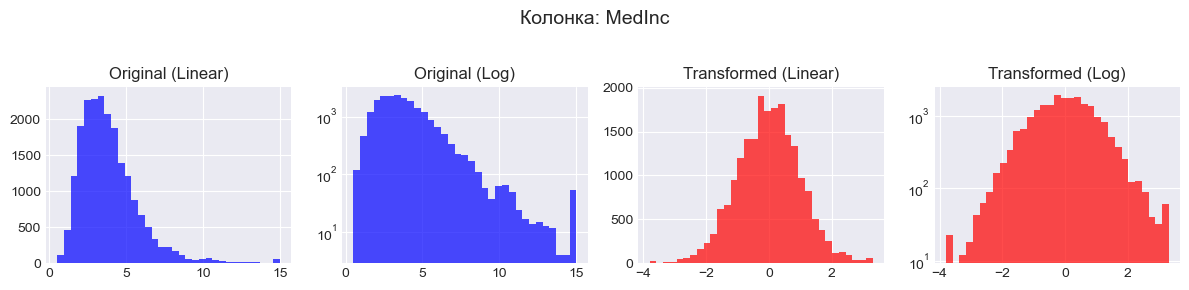

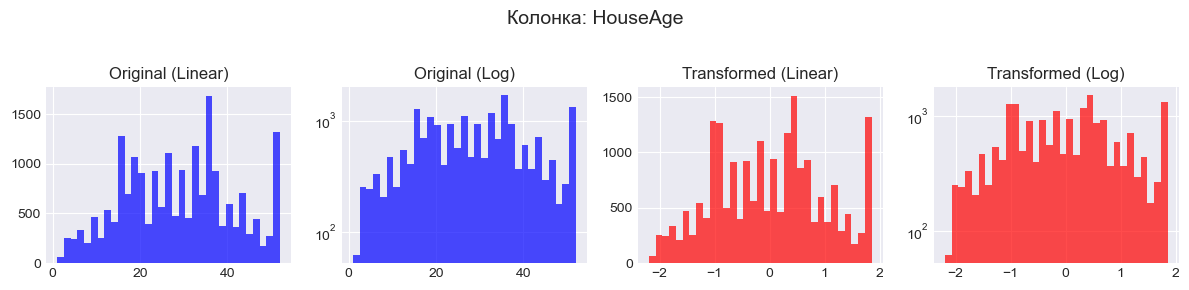

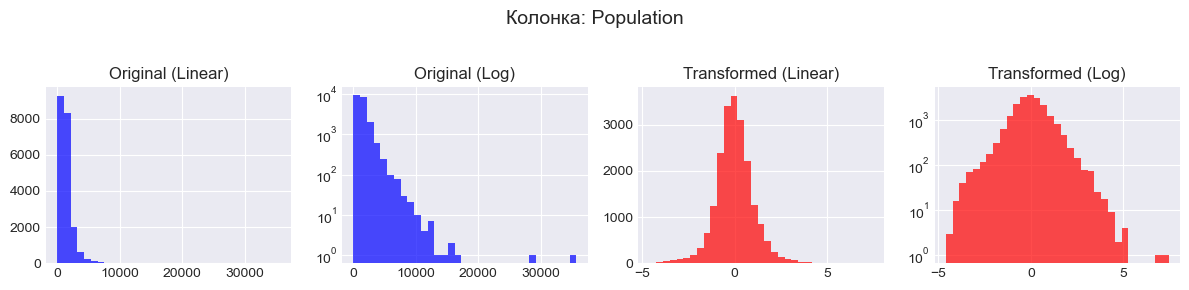

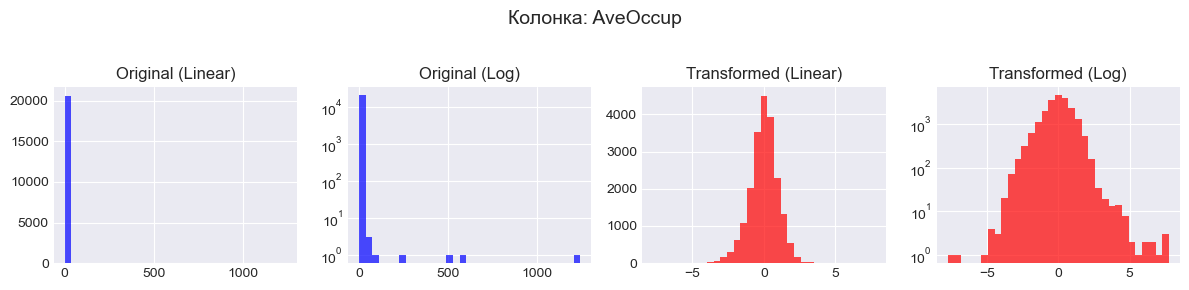

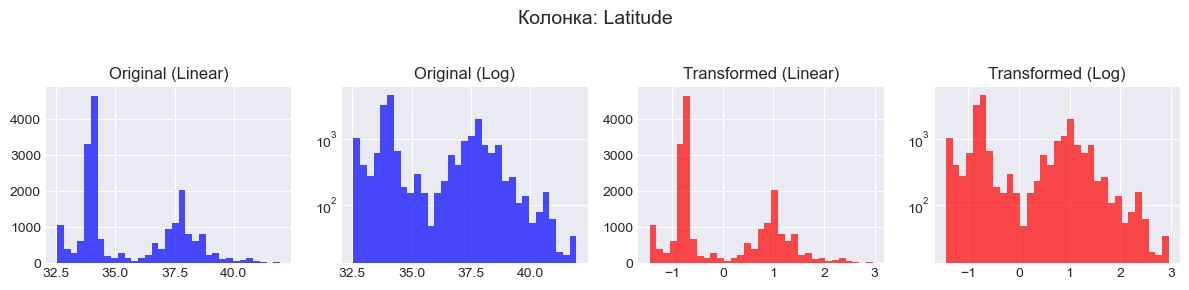

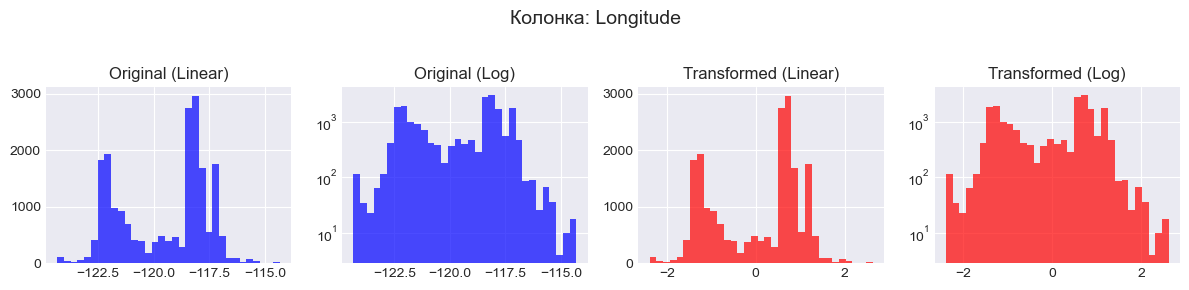

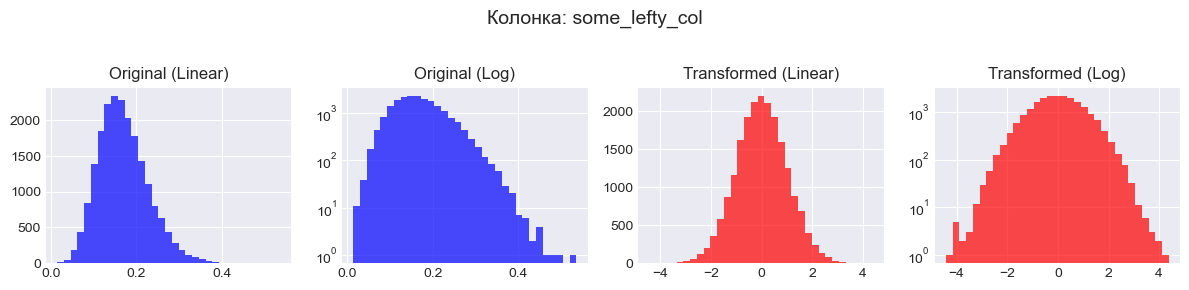

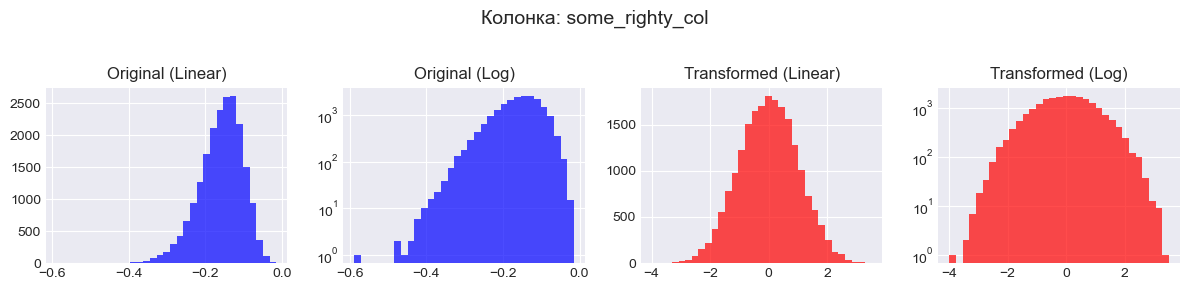

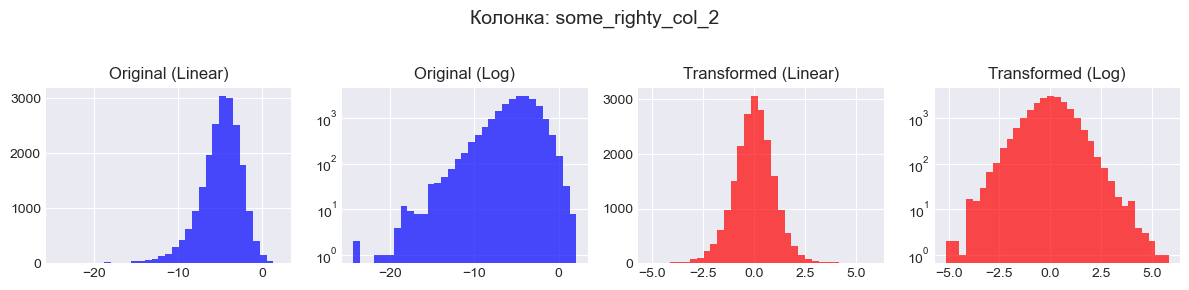

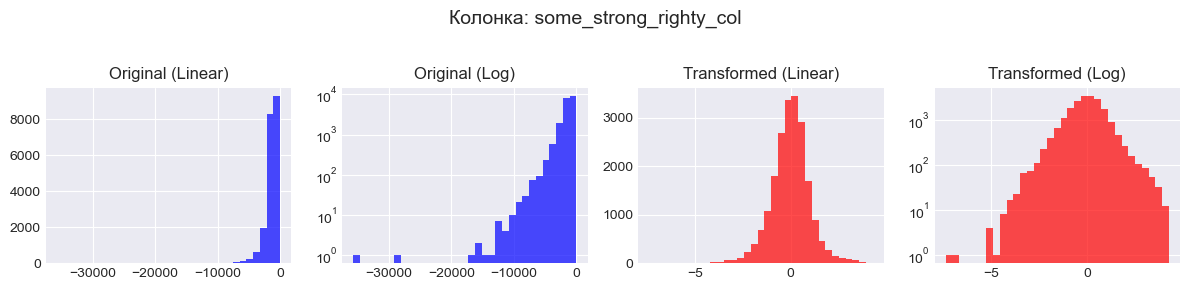

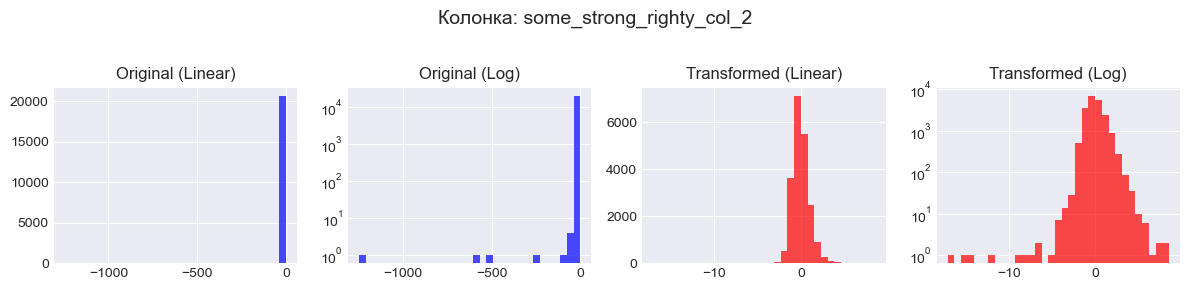

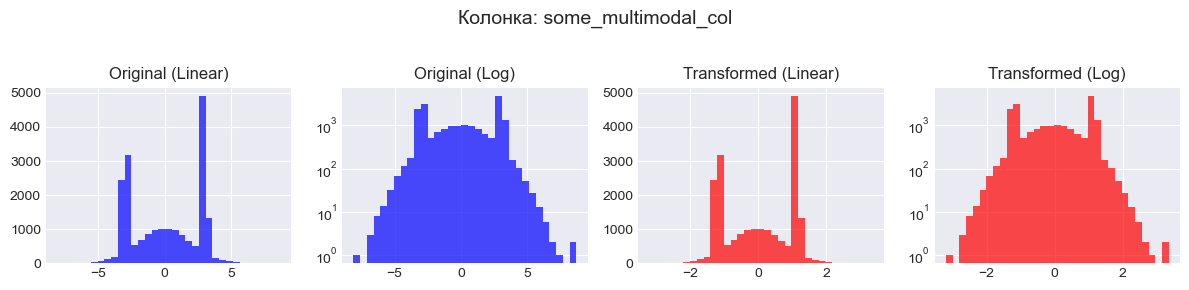

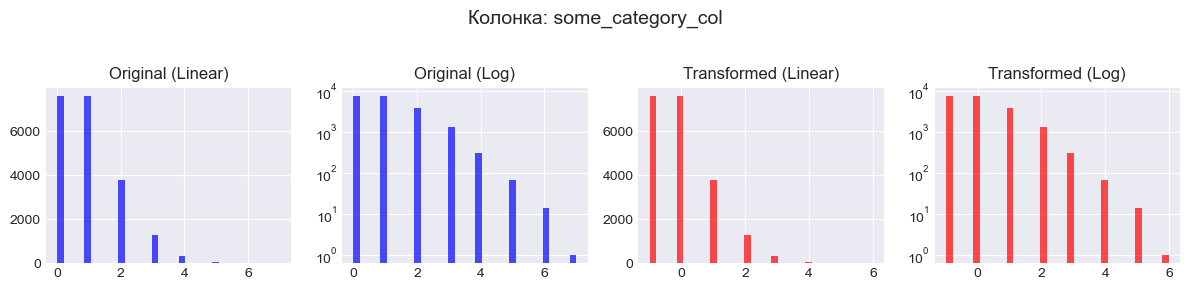

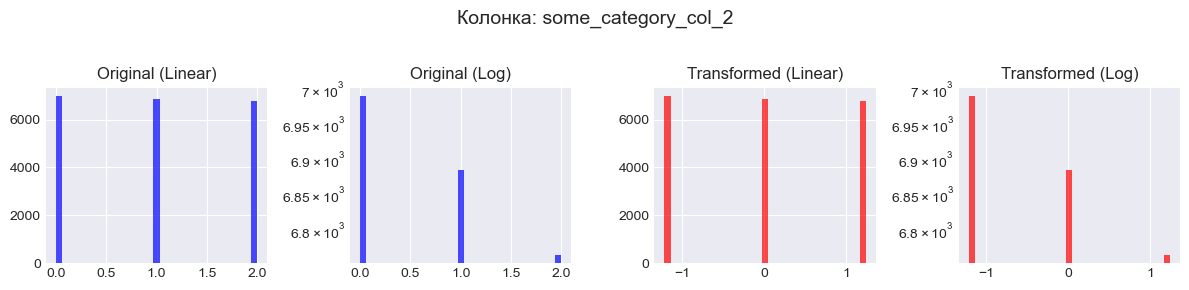

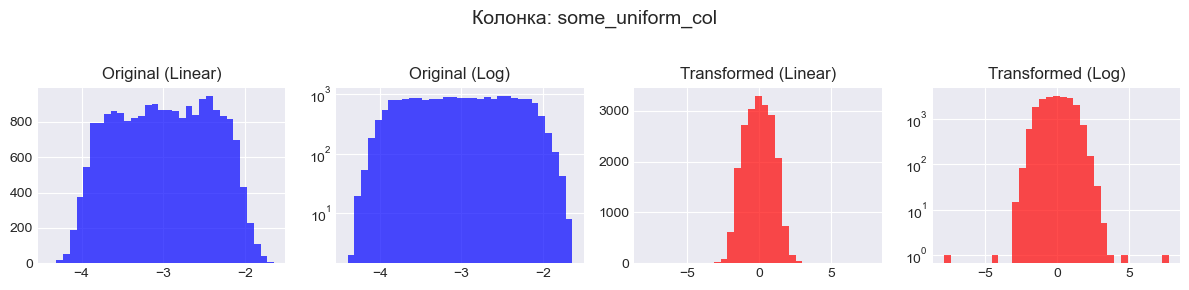

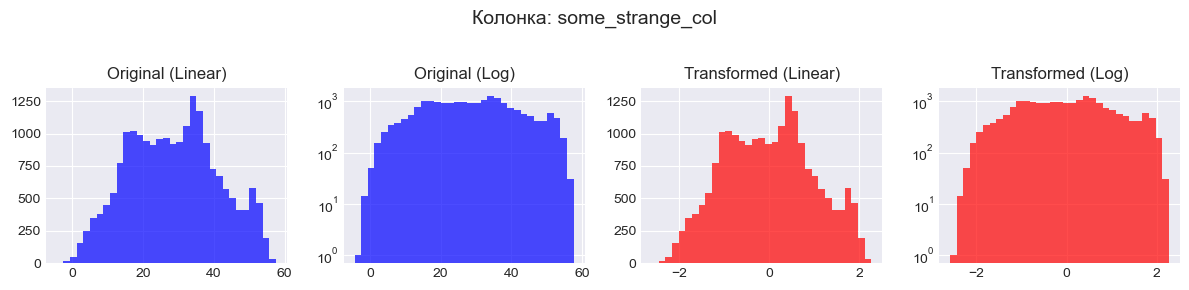

In [5]:
transformer = FeatureTransformer(
    scaler='StandardScaler', use_quantile_transformer=False)

df_transformed = transformer.fit_transform(df)

plot_comparison(df, df_transformed)